# Visualization & Diagnostics

History matching produces a lot to look at — emulator fits, the shrinking
plausible region, how close the simulated outputs sit to their targets. This
notebook tours the built-in plotting and display API on the stochastic SIR model
used throughout these tutorials.

Every `plot_*` method returns Matplotlib axes and accepts an `ax=` argument, so
the figures render inline and compose into your own layouts. The same figures are
written to the engine's `output_dir` after each wave.

See the [Diagnostics & plotting](../diagnostics.md) guide for how to interpret
each figure.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import historymatching as hm
from model import SIR, generate_observed_data

%matplotlib inline
np.random.seed(0)

2026-05-31 15:02:30.214016: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-31 15:02:30.214676: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-31 15:02:30.216828: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-31 15:02:30.222765: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780264950.232401  171786 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780264950.23

/home/cliffk/historymatching/.venv/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


/home/cliffk/historymatching/.venv/lib/python3.12/site-packages/gpflow/versions.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Set up and run a calibration

We recover the transmission/recovery rates of a synthetic outbreak, then use the
result to demonstrate each plot. (See `01_basic_workflow.ipynb` for the workflow
itself in detail.)

In [ ]:
beta_true, gamma_true = 1.3, 0.5
population_size, n_seed = 10_000, 100
incidence_obs, _ = generate_observed_data(beta_true=beta_true, gamma_true=gamma_true,
                                          population_size=population_size,
                                          n_seed_infections=n_seed)

def sir_sim(samples: pd.DataFrame) -> pd.DataFrame:
    df = samples.copy()
    if "rand_seed" not in df.columns:
        df["rand_seed"] = np.random.default_rng(0).integers(0, 2**31, size=len(df))
    rows = []
    for _, row in df.iterrows():
        model = SIR(beta=row["beta"], gamma=row["gamma"],
                    s0=population_size - n_seed, i0=n_seed, seed=int(row["rand_seed"]))
        inc = model.get_incidence()
        rec = {f"incidence_{i}": inc[i] for i in range(len(inc))}
        rec["peak_incidence"] = inc.max()
        rec["total_cases"] = inc.sum()
        rows.append(rec)
    return pd.DataFrame(rows)

observations = {
    "peak_incidence": (incidence_obs.max(), 50),
    "total_cases":    (incidence_obs.sum(), 200),
    "incidence_10":   (incidence_obs.iloc[10], 40),
}

engine = hm.HistoryMatching(
    parameter_bounds={"beta": (0.5, 3.0), "gamma": (0.1, 1.0)},
    observations=observations,
    function=sir_sim,
    emulator_type="gpr",
    n_samples=300,
    max_iterations=3,
    random_seed=123,
    feature_selection=["peak_incidence", "incidence_10"],
    output_dir=None,  # focus on interactive plots; no files written here
)
results = engine.run()
print(f"Completed {len(results)} waves.")

## Text summaries

`engine.summary()` folds the per-wave convergence and the surviving parameter
ranges into one report. `engine.nroy_summary()` returns the same per-parameter
information as a tidy DataFrame.

In [3]:
print(engine.summary())

=== History Matching Summary ===
Waves completed:   3/3
Emulators trained: 6
Samples generated: 17,236
Samples accepted:  1,800
Acceptance rate:   8.703%

NROY fraction per wave:
  Wave 1:   5.823%   features: peak_incidence, incidence_10
  Wave 2:   5.543%   features: peak_incidence, incidence_10
  Wave 3:   4.708%   features: peak_incidence, incidence_10

Plausible (NROY) parameter ranges  [300 samples]:
  beta                 [0.9579, 1.832]   median 1.418   (2.9× narrower)
  gamma                [0.1667, 0.9995]   median 0.6008   (1.1× narrower)


In [4]:
engine.nroy_summary()

,min,max,median,q05,q95,reduction
parameter,,,,,,
beta,0.957875,1.832411,1.418258,1.067301,1.752751,2.858661
gamma,0.166677,0.999536,0.600823,0.269911,0.926973,1.080616


## Convergence

The NROY fraction is the share of fresh prior samples passing *all* emulator
constraints so far. A steadily falling fraction means the calibration is
successfully ruling out parameter space.

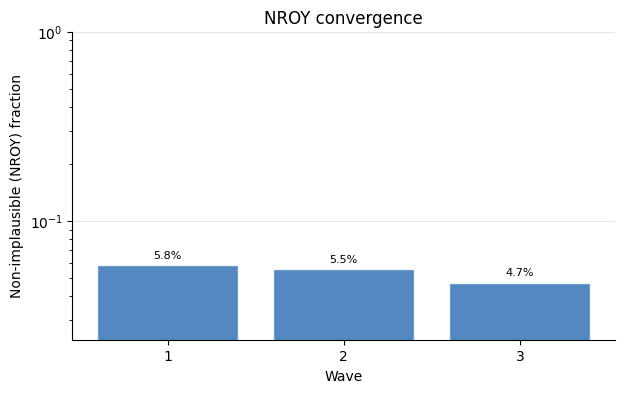

In [5]:
engine.plot_convergence();

## The NROY parameter cloud

The headline result: a corner plot of the non-implausible region — marginals on
the diagonal, pairwise scatter below. We overlay the known true values with
`truth=`.

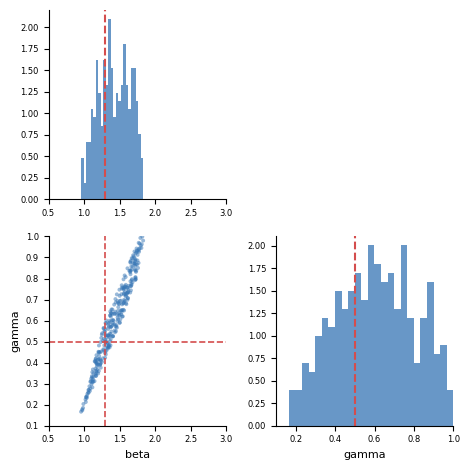

In [6]:
truth = {"beta": beta_true, "gamma": gamma_true}
engine.plot_nroy(truth=truth);

`plot_marginals` shows just the one-dimensional posteriors, with the sample
median and the true value marked.

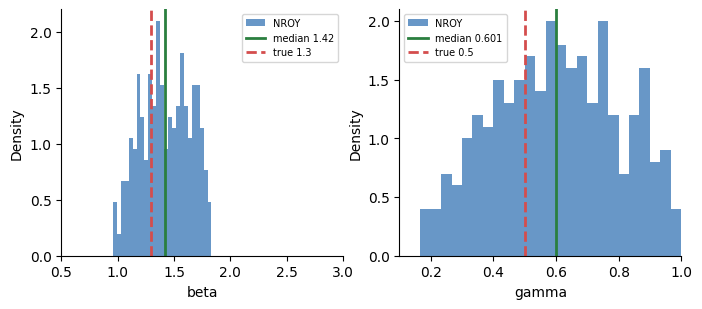

In [7]:
engine.plot_marginals(truth=truth);

## Z-scores vs targets

For every target, the distribution of `(simulated - target) / target_std` across
the NROY samples, by wave. Bands inside the green ±threshold region and centred
on zero are consistent with the data.

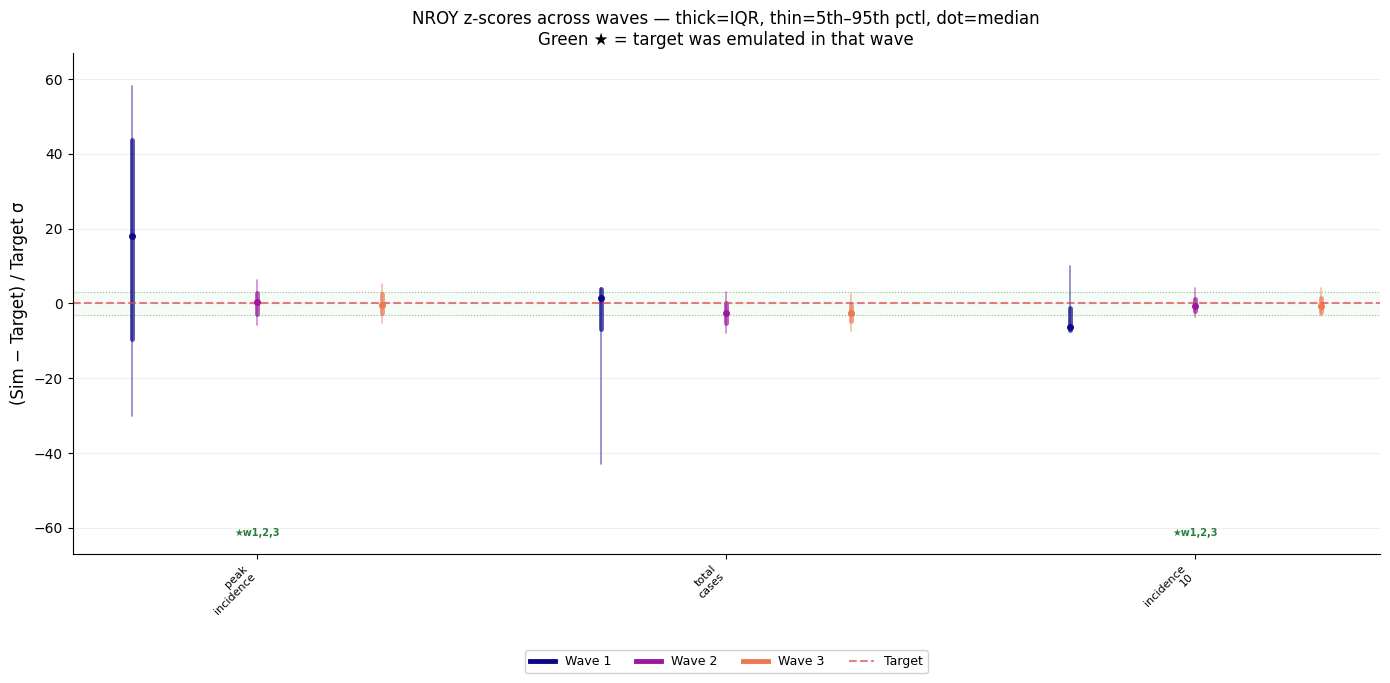

In [8]:
engine.plot_zscores();

## Constrained directions

A PCA view of which *combinations* of parameters the data constrained most —
useful for spotting non-identifiable directions that marginal plots miss.

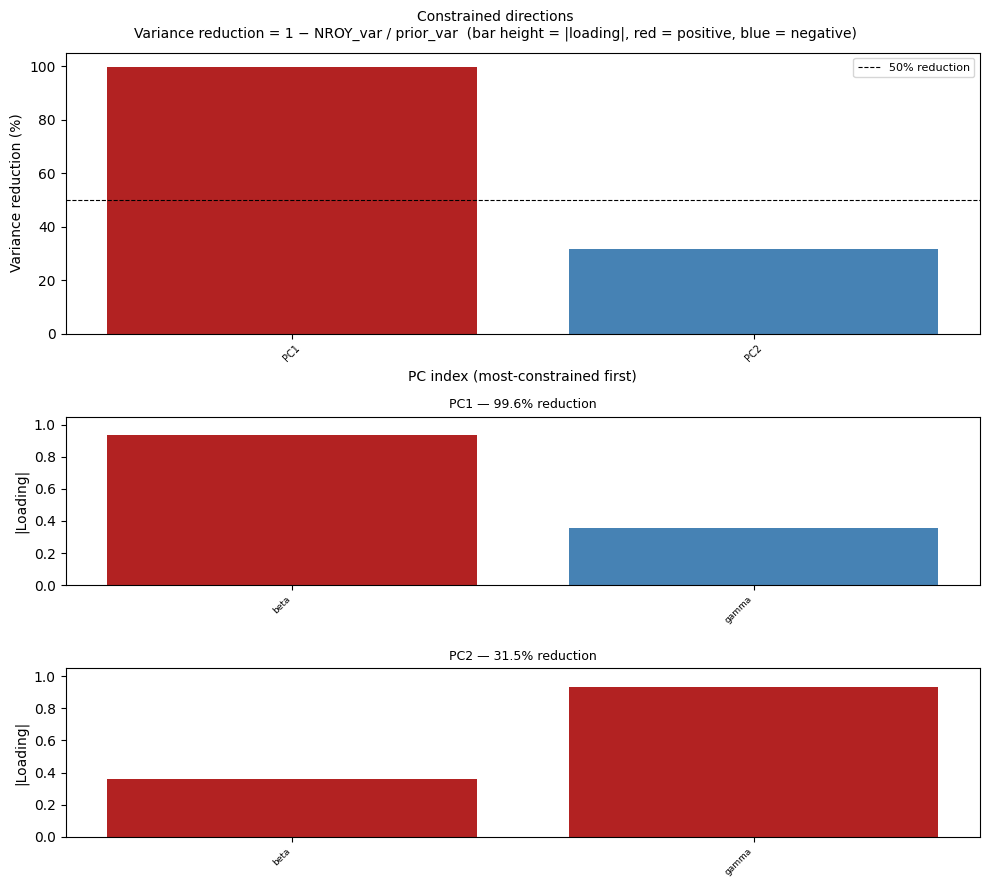

In [9]:
engine.plot_constrained_dims(n_top=2);

## Emulator quality

The emulators are only trustworthy if they reproduce the simulator. Inspect the
fit per feature for the final wave.

In [10]:
final = results[-1]
final.quality_table()

,r2,mse,n_train
feature,,,
peak_incidence,0.807161,4550.610556,225
incidence_10,0.837472,1469.290292,225


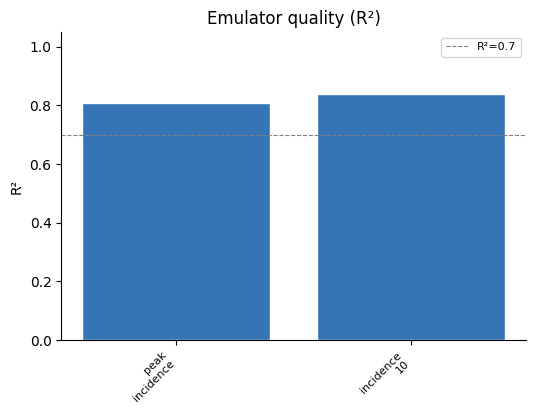

In [11]:
final.plot_emulator_quality();

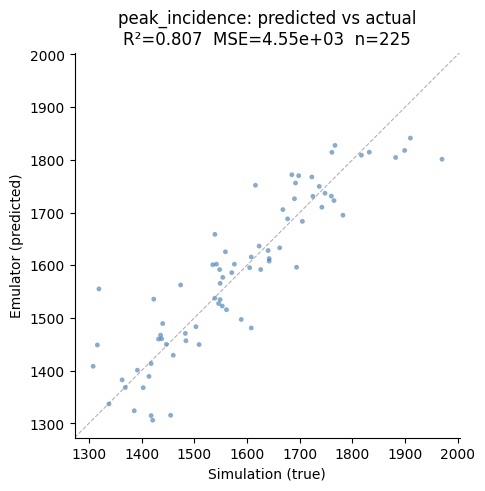

In [12]:
final.plot_predicted_vs_actual("peak_incidence");

## Ensemble fan plot vs observed data

History matching constrains *parameters*; to check the *outputs*, re-run the
simulator at NROY parameter sets and compare the trajectories to the observed
data. `hm.plot_ensemble_fan` is model-agnostic — give it a 2-D array of
trajectories and an observed series.

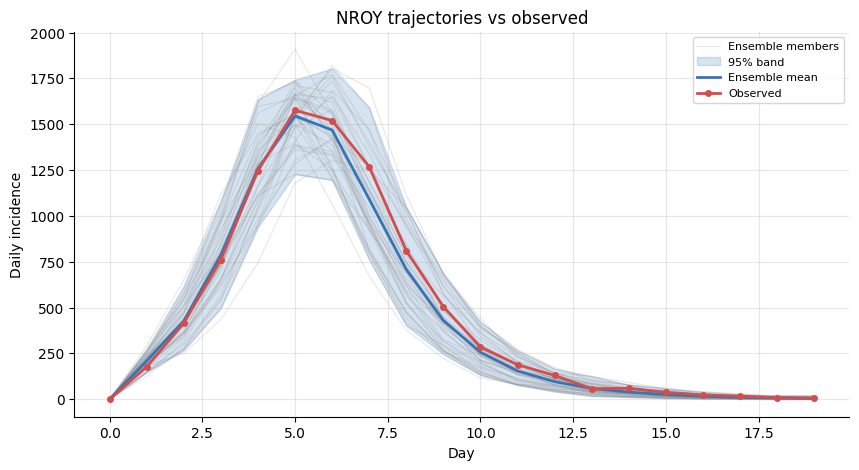

In [13]:
nroy = engine.get_nroy_samples(40, method="lhs")  # unbiased draw
trajectories = np.array([
    SIR(beta=r["beta"], gamma=r["gamma"], s0=population_size - n_seed, i0=n_seed).get_incidence()
    for _, r in nroy.iterrows()
])
hm.plot_ensemble_fan(trajectories, observed=incidence_obs.values,
                     xlabel="Day", ylabel="Daily incidence",
                     title="NROY trajectories vs observed");

## Domain-object views

`ParameterSpace`, `ObservationData`, and `EmulatorBank` each have a `summary()`
and (where it makes sense) a plot.

In [14]:
print(engine.parameter_space.summary())
print()
print(engine.observations.summary())
print()
print(engine.emulator_bank.summary())

ParameterSpace: 2 parameters
  beta                 [0.5, 3]   width 2.5
  gamma                [0.1, 1]   width 0.9

ObservationData: 3 features
  peak_incidence       1576 ± 50
  total_cases          9091 ± 200
  incidence_10         285 ± 40

EmulatorBank: 6 emulators across 3 waves
  Wave 1: ['peak_incidence', 'incidence_10']
  Wave 2: ['peak_incidence', 'incidence_10']
  Wave 3: ['peak_incidence', 'incidence_10']


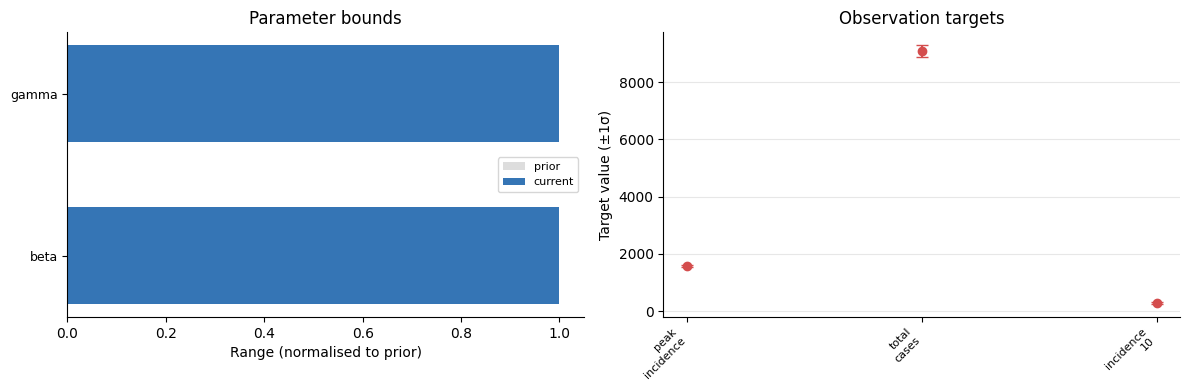

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
engine.parameter_space.plot_bounds(reference=engine.parameter_space, ax=axes[0])
engine.observations.plot_targets(ax=axes[1])
plt.tight_layout();

All of these methods return Matplotlib axes, so you can drop them into your
own multi-panel figures (as above) or save them with `fig.savefig(...)`. For the
full catalogue and reading guidance, see the
[Diagnostics & plotting](../diagnostics.md) guide.